# Phase 1: Data Understanding & Preprocessing
## Lending Club Loan Dataset — Data Mining Project

**Mining Angle**: Cluster borrowers by risk profile using grade, income, and debt ratio.  
**Mining Rules Target**: Borrowers stating small business as loan purpose with 10+ years of employment tend to receive Grade A loans with low interest rates.

---

### Tahapan Phase 1:
1. **Data Understanding & EDA** — Explore distribusi, missing values, data types, outliers
2. **Data Cleaning** — Handle nulls, fix inconsistencies, remove duplicates
3. **Data Transformation** — Log transform, encoding, binning, standard scaling
4. **Feature Selection** — Correlation analysis & entropy measures → <10 dimensi
5. **Save & Report** — Export clean dataset & preprocessing report

---
## Step 1: Data Understanding & Exploratory Data Analysis (EDA)

### 1.1 — Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif, VarianceThreshold
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
sns.set_theme(style='whitegrid', palette='viridis')

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load dataset (reading ~890K records as per project requirement to prevent out-of-memory)
df = pd.read_csv("accepted_2007_to_2018Q4.csv", low_memory=False, nrows=890000)

print(f"Dataset loaded successfully!")
print(f"Rows   : {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"Memory : {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")
print()
df.head(3)

Dataset loaded successfully!
Rows   : 890,000
Columns: 151
Memory : 2.46 GB



,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


### 1.2 — Overview Struktur Data

In [3]:
print("=" * 60)
print("DATA TYPES SUMMARY")
print("=" * 60)
dtype_counts = df.dtypes.value_counts()
for dtype, count in dtype_counts.items():
    print(f"  {str(dtype):20s} : {count} columns")

print(f"\nTotal columns: {df.shape[1]}")

DATA TYPES SUMMARY
  float64              : 113 columns
  str                  : 38 columns

Total columns: 151


In [4]:
print("=" * 60)
print("DESCRIPTIVE STATISTICS (Numeric Features)")
print("=" * 60)
df.describe().T

DESCRIPTIVE STATISTICS (Numeric Features)


,count,mean,std,min,25%,50%,75%,max
member_id,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,889990.0,15312.931128,9224.517421,1000.00,8000.0000,13450.000,20000.0000,40000.00
funded_amnt,889990.0,15312.899667,9224.519462,1000.00,8000.0000,13450.000,20000.0000,40000.00
funded_amnt_inv,889990.0,15307.789885,9222.241209,750.00,8000.0000,13450.000,20000.0000,40000.00
int_rate,889990.0,12.742516,4.803929,5.31,9.1700,12.290,15.6100,30.99
...,...,...,...,...,...,...,...,...
hardship_payoff_balance_amount,4678.0,10926.400239,7407.908616,55.73,5076.5450,9332.135,15227.0175,40306.41
hardship_last_payment_amount,4678.0,189.354585,193.087490,0.01,43.4475,129.755,279.1800,1290.59
settlement_amount,15584.0,5007.409916,3670.731762,107.00,2193.0000,4212.835,6885.0225,30000.00
settlement_percentage,15584.0,47.707354,6.528843,0.45,45.0000,45.000,50.0000,166.67


### 1.3 — Missing Values Analysis

In [5]:
# Calculate missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

total_cols = df.shape[1]
cols_no_missing = total_cols - len(missing_df)

print("MISSING VALUES SUMMARY")
print("=" * 60)
print(f"  Columns tanpa missing     : {cols_no_missing}")
print(f"  Columns dengan missing     : {len(missing_df)}")
print(f"  ├── >50% missing (DROP)    : {len(missing_df[missing_df['Missing %'] > 50])}")
print(f"  ├── 20-50% missing         : {len(missing_df[(missing_df['Missing %'] > 20) & (missing_df['Missing %'] <= 50)])}")
print(f"  └── <20% missing (IMPUTE)  : {len(missing_df[missing_df['Missing %'] <= 20])}")

print("\nAll columns with missing values:")
display(missing_df)

MISSING VALUES SUMMARY
  Columns tanpa missing     : 1
  Columns dengan missing     : 150
  ├── >50% missing (DROP)    : 45
  ├── 20-50% missing         : 13
  └── <20% missing (IMPUTE)  : 92

All columns with missing values:


,Missing Count,Missing %
member_id,890000,100.00
desc,889949,99.99
orig_projected_additional_accrued_interest,886249,99.58
hardship_payoff_balance_amount,885322,99.47
payment_plan_start_date,885322,99.47
...,...,...
num_il_tl,10,0.00
num_op_rev_tl,10,0.00
hardship_flag,10,0.00
disbursement_method,10,0.00


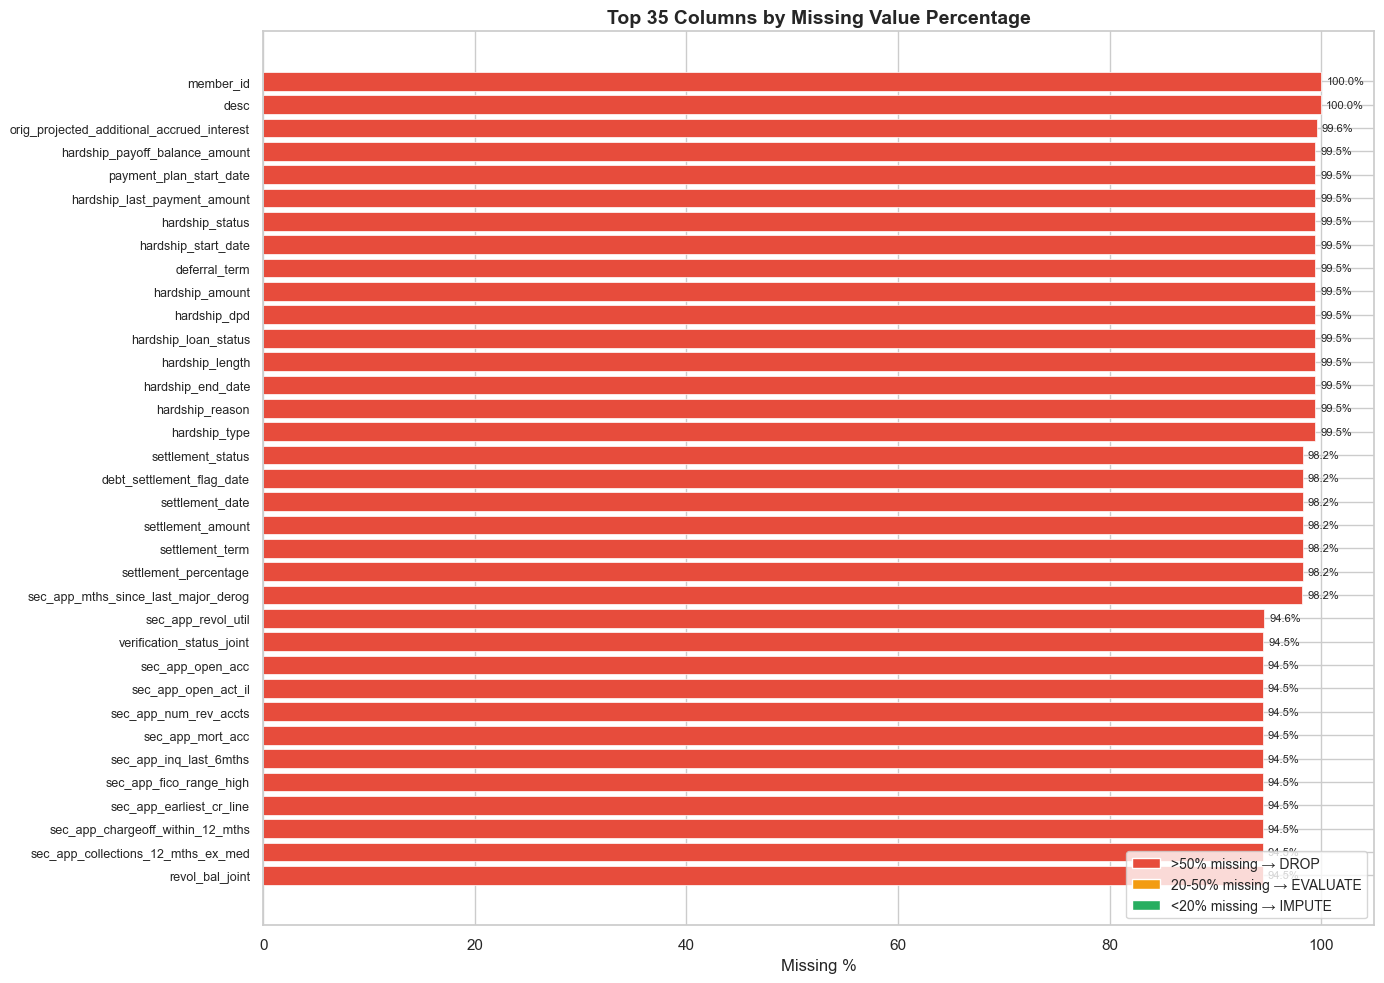

In [6]:
# Visualisasi Missing Values
fig, ax = plt.subplots(figsize=(14, 10))
top_missing = missing_df.head(35)

colors = []
for pct in top_missing['Missing %']:
    if pct > 50:
        colors.append('#e74c3c')   # merah — akan di-drop
    elif pct > 20:
        colors.append('#f39c12')   # orange — evaluasi
    else:
        colors.append('#27ae60')   # hijau — impute

bars = ax.barh(range(len(top_missing)), top_missing['Missing %'].values, color=colors, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(top_missing)))
ax.set_yticklabels(top_missing.index, fontsize=9)
ax.set_xlabel('Missing %')
ax.set_title('Top 35 Columns by Missing Value Percentage', fontsize=14, fontweight='bold')
ax.invert_yaxis()

for bar, val in zip(bars, top_missing['Missing %'].values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='>50% missing → DROP'),
    Patch(facecolor='#f39c12', label='20-50% missing → EVALUATE'),
    Patch(facecolor='#27ae60', label='<20% missing → IMPUTE')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

### 1.4 — Distribusi Fitur Numerik

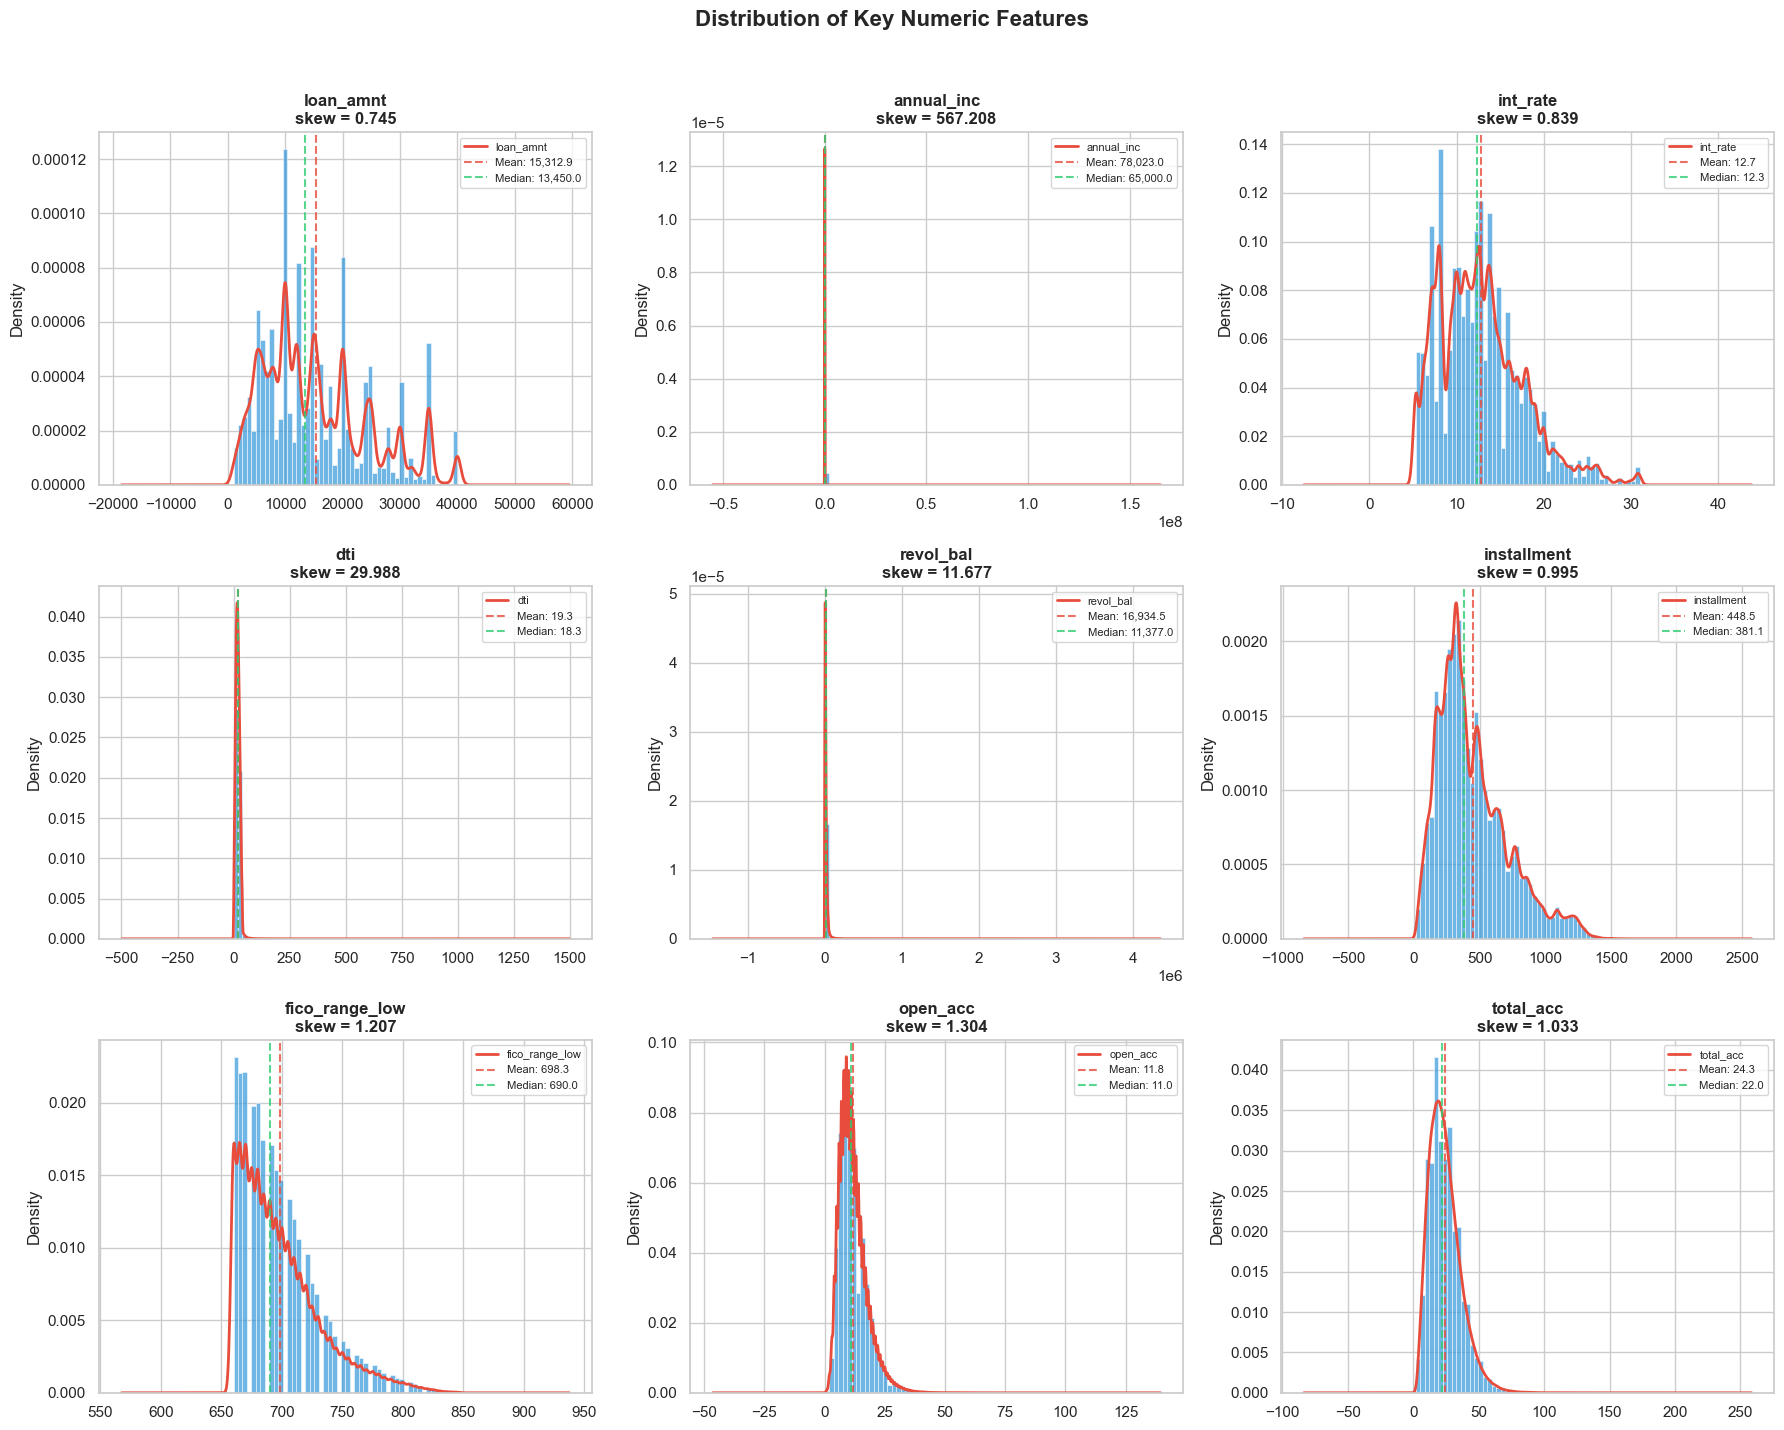


Skewness Summary:
----------------------------------------
  loan_amnt           :    0.745
  annual_inc          :  567.208 ⚠️ HIGH SKEW
  int_rate            :    0.839
  dti                 :   29.988 ⚠️ HIGH SKEW
  revol_bal           :   11.677 ⚠️ HIGH SKEW
  installment         :    0.995
  fico_range_low      :    1.207
  open_acc            :    1.304
  total_acc           :    1.033


In [7]:
# Histogram & KDE untuk fitur-fitur kunci
key_numeric = ['loan_amnt', 'annual_inc', 'int_rate', 'dti', 'revol_bal',
               'installment', 'fico_range_low', 'open_acc', 'total_acc']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
for i, col in enumerate(key_numeric):
    ax = axes[i // 3, i % 3]
    data = df[col].dropna()
    ax.hist(data, bins=50, alpha=0.7, color='#3498db', edgecolor='white', linewidth=0.5, density=True)
    data.plot.kde(ax=ax, color='#e74c3c', linewidth=2)
    ax.axvline(data.mean(), color='#e74c3c', linestyle='--', alpha=0.8, label=f'Mean: {data.mean():,.1f}')
    ax.axvline(data.median(), color='#2ecc71', linestyle='--', alpha=0.8, label=f'Median: {data.median():,.1f}')
    ax.set_title(f'{col}\nskew = {data.skew():.3f}', fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Distribution of Key Numeric Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print skewness summary
print("\nSkewness Summary:")
print("-" * 40)
for col in key_numeric:
    skew = df[col].skew()
    flag = " ⚠️ HIGH SKEW" if abs(skew) > 1.5 else ""
    print(f"  {col:20s}: {skew:8.3f}{flag}")

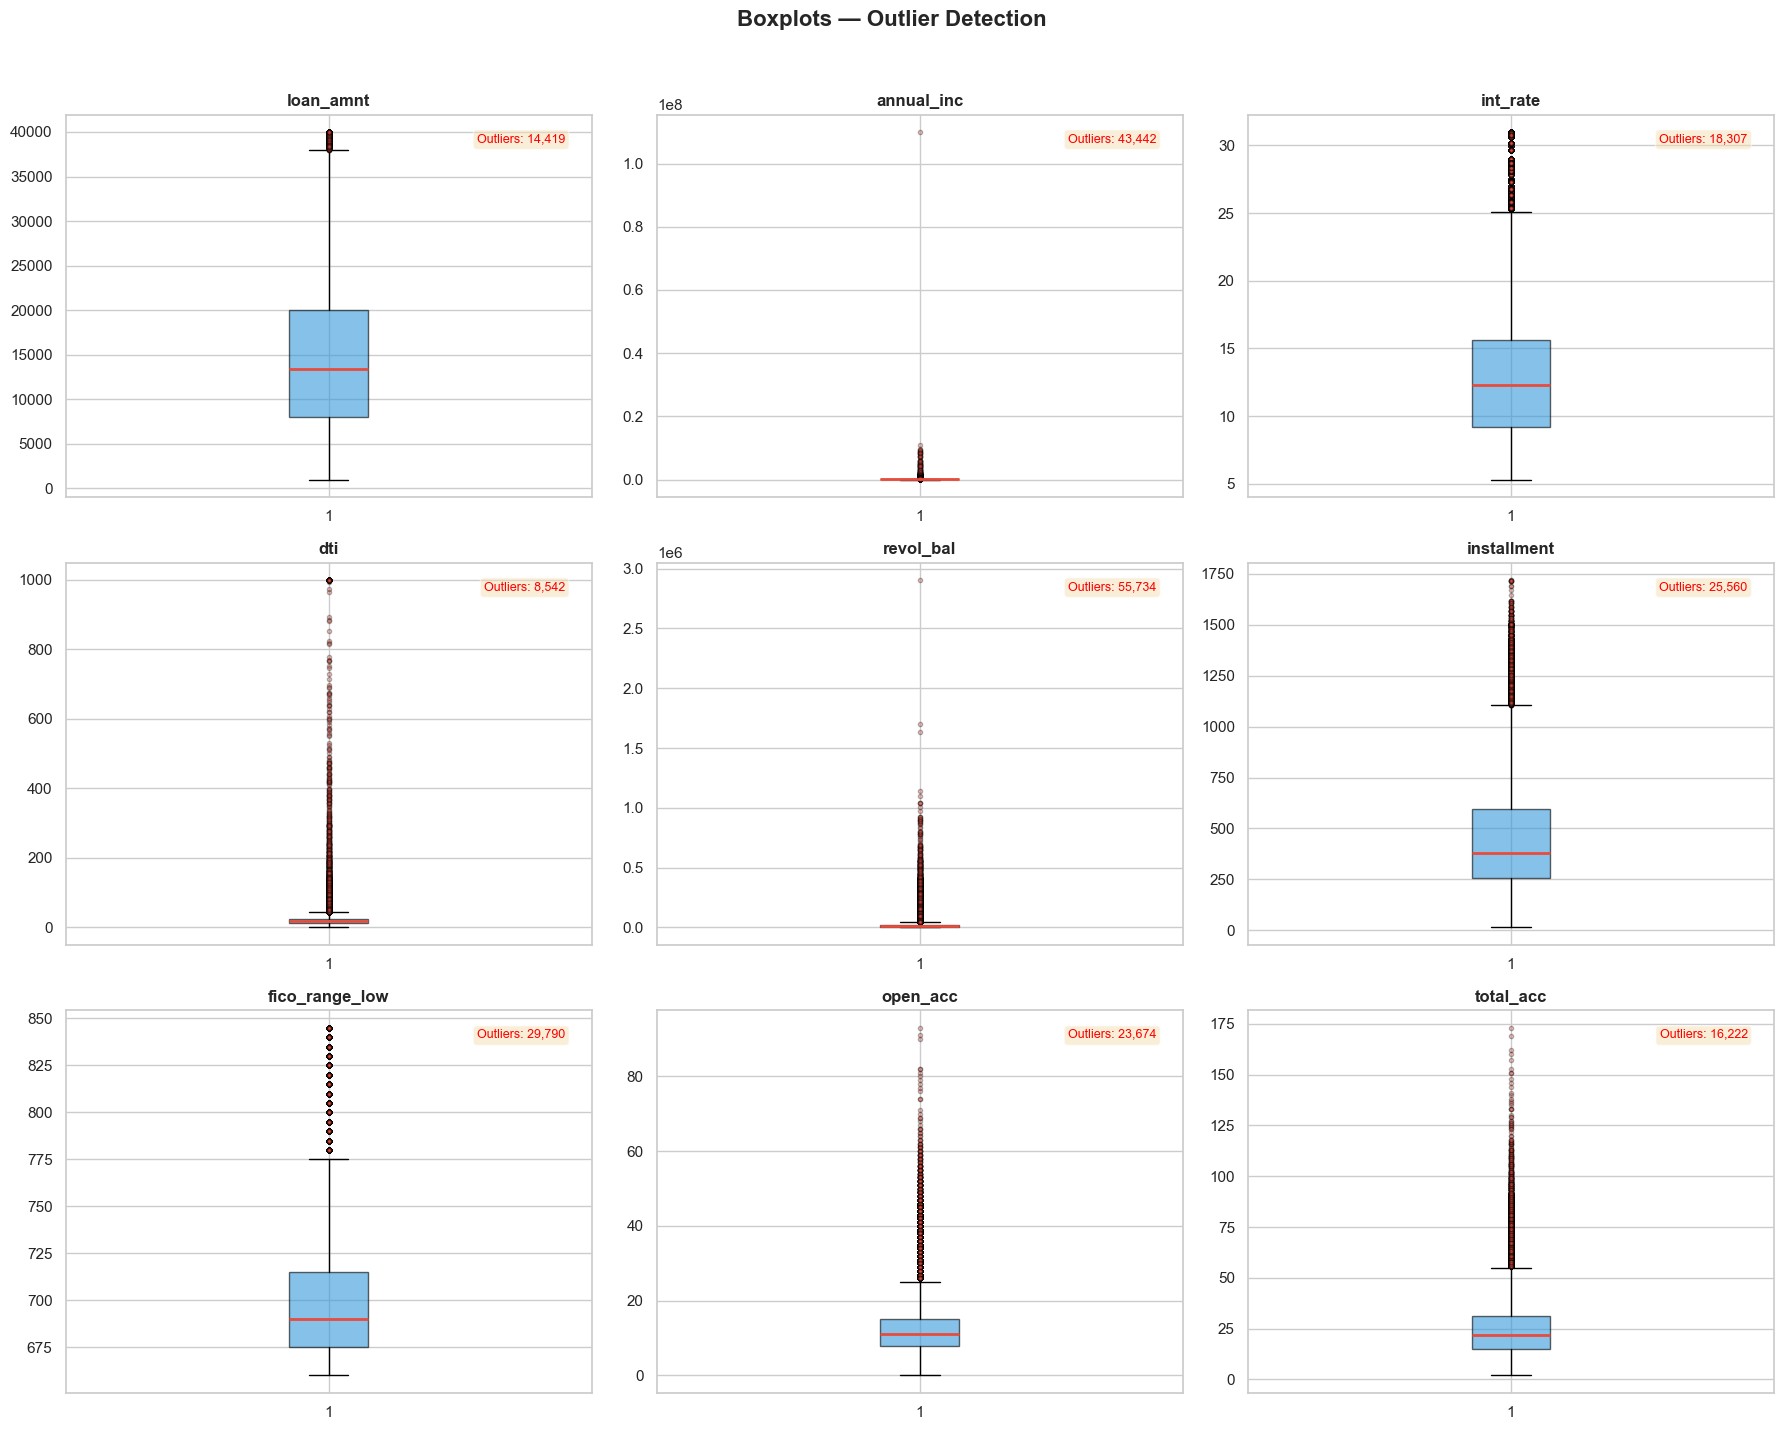

In [8]:
# Boxplot untuk deteksi outliers
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
for i, col in enumerate(key_numeric):
    ax = axes[i // 3, i % 3]
    data = df[col].dropna()
    bp = ax.boxplot(data, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.6),
                    medianprops=dict(color='#e74c3c', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor='#e74c3c', markersize=3, alpha=0.3))
    ax.set_title(col, fontweight='bold')

    # Count outliers (IQR method)
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((data < Q1 - 1.5 * IQR) | (data > Q3 + 1.5 * IQR)).sum()
    ax.text(0.95, 0.95, f'Outliers: {outliers:,}', transform=ax.transAxes,
            ha='right', va='top', fontsize=9, color='red',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Boxplots — Outlier Detection', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 1.5 — Distribusi Fitur Kategorik

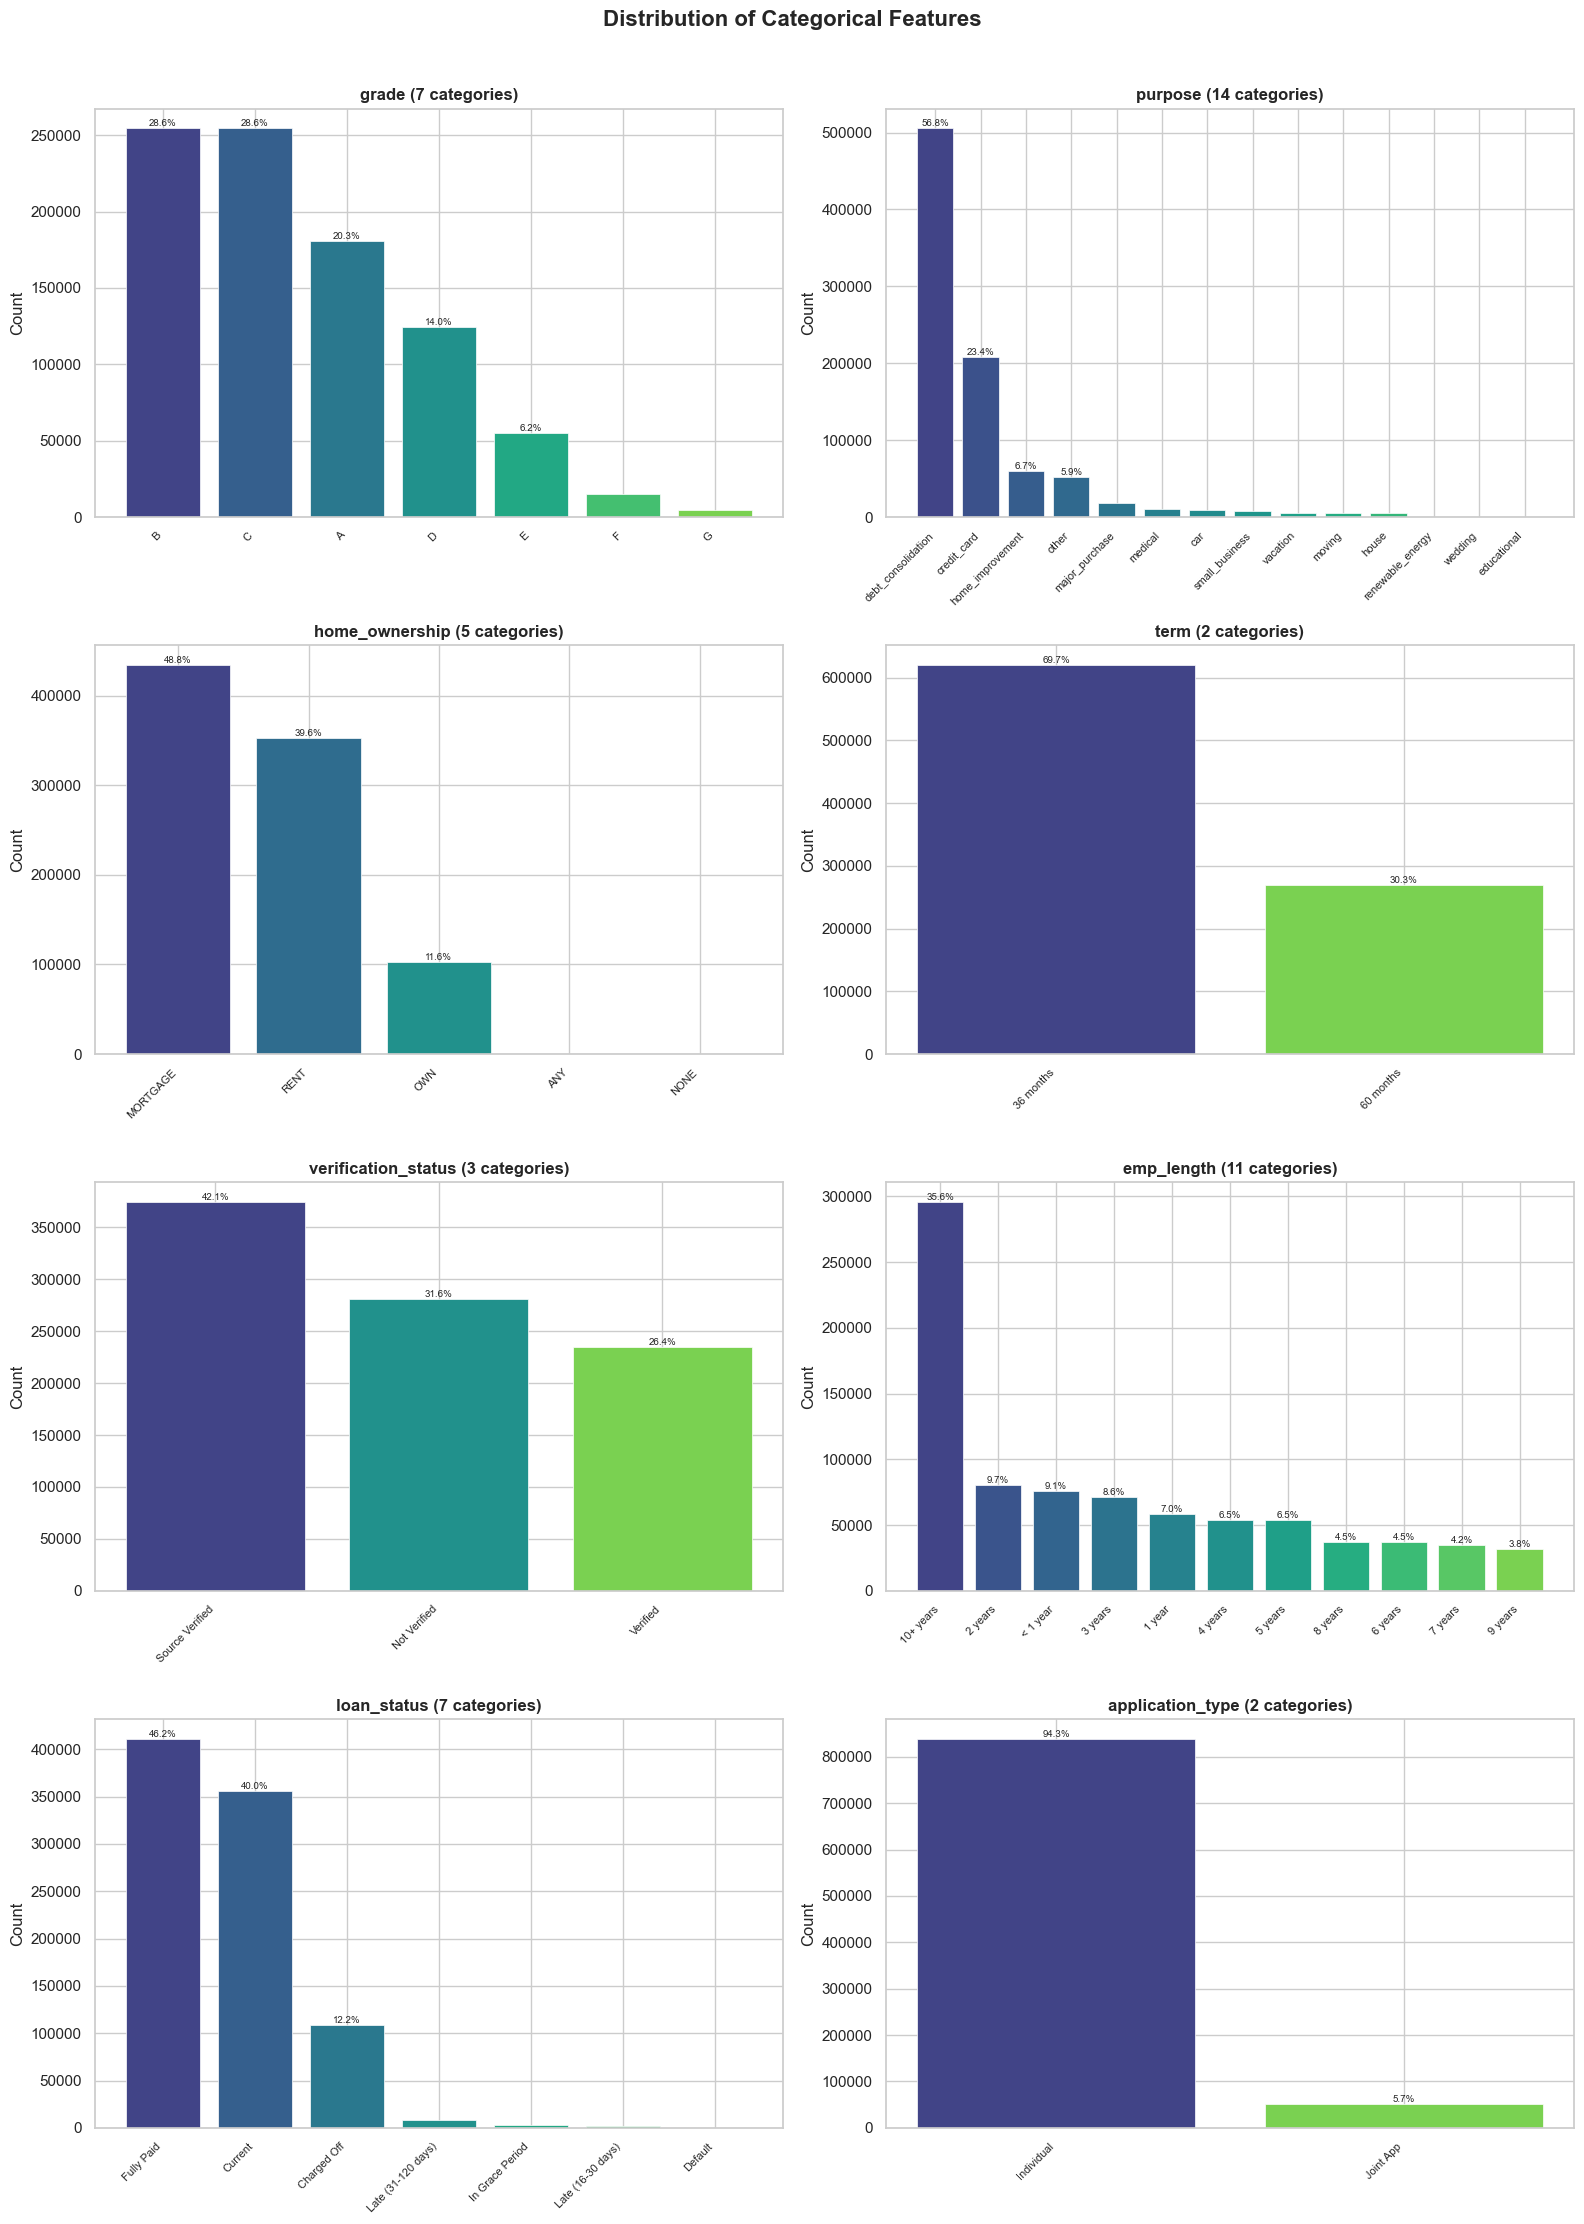

In [9]:
cat_cols = ['grade', 'purpose', 'home_ownership', 'term',
            'verification_status', 'emp_length', 'loan_status', 'application_type']

fig, axes = plt.subplots(4, 2, figsize=(16, 22))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    counts = df[col].value_counts()
    n_cats = len(counts)
    palette = plt.cm.viridis(np.linspace(0.2, 0.8, n_cats))
    bars = ax.bar(range(n_cats), counts.values, color=palette, edgecolor='white', linewidth=0.5)
    ax.set_xticks(range(n_cats))
    ax.set_xticklabels(counts.index, rotation=45, ha='right', fontsize=8)
    ax.set_title(f'{col} ({n_cats} categories)', fontweight='bold')
    ax.set_ylabel('Count')

    # Add percentage labels
    total = counts.sum()
    for bar, val in zip(bars, counts.values):
        pct = val / total * 100
        if pct > 3:  # Only label if > 3%
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                    f'{pct:.1f}%', ha='center', va='bottom', fontsize=7)

plt.suptitle('Distribution of Categorical Features', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 1.6 — Correlation Analysis (Awal)

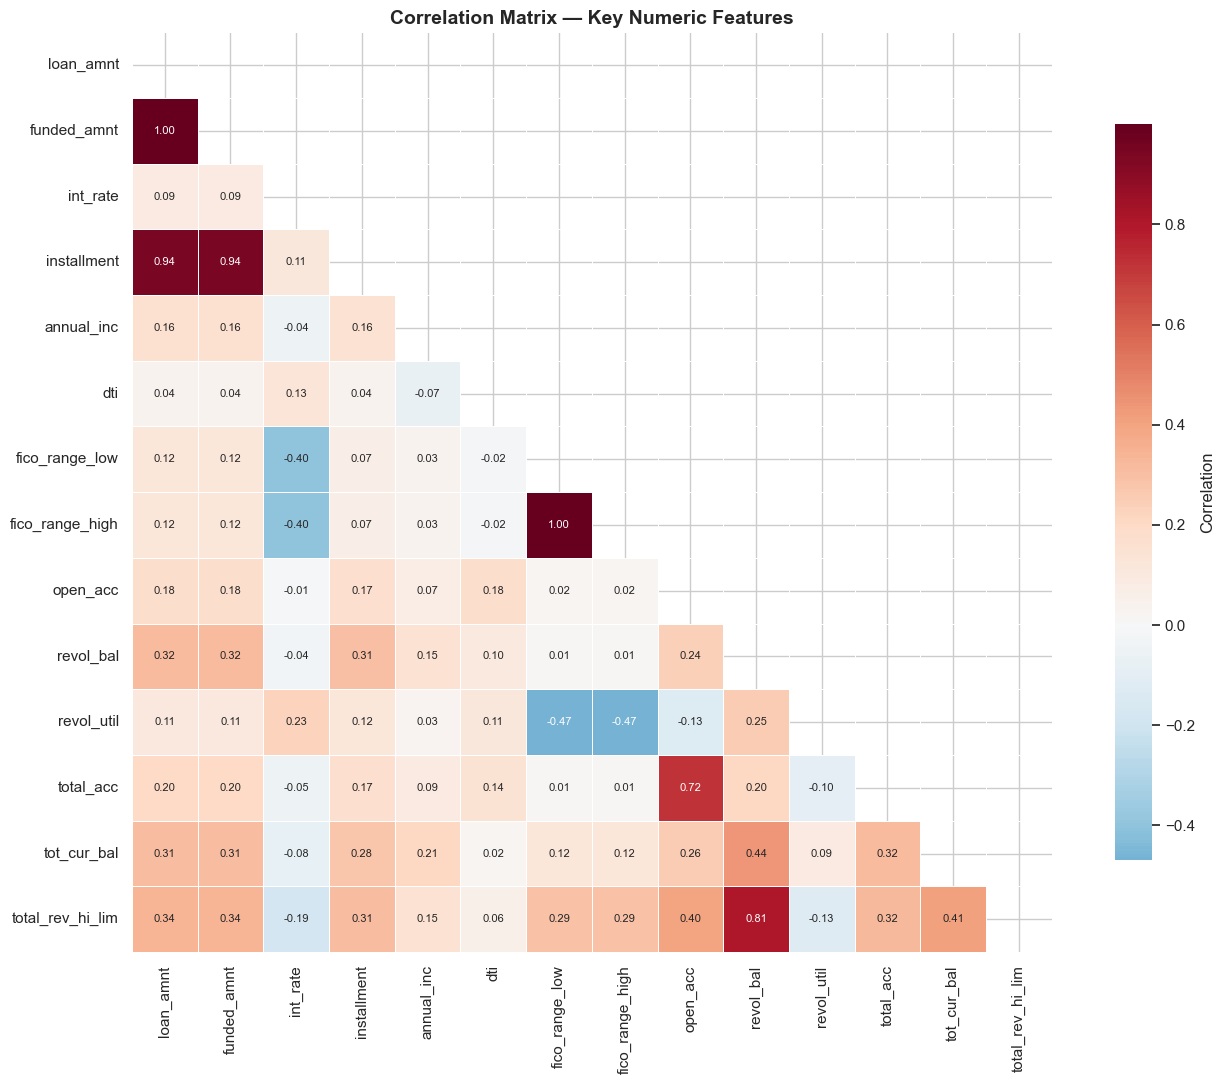


Highly Correlated Pairs (|r| > 0.80):
  loan_amnt                 vs funded_amnt               : r = 1.000
  loan_amnt                 vs installment               : r = 0.943
  funded_amnt               vs installment               : r = 0.943
  fico_range_low            vs fico_range_high           : r = 1.000
  revol_bal                 vs total_rev_hi_lim          : r = 0.808


In [10]:
# Correlation matrix untuk fitur numerik kunci
corr_cols = ['loan_amnt', 'funded_amnt', 'int_rate', 'installment', 'annual_inc',
             'dti', 'fico_range_low', 'fico_range_high', 'open_acc', 'revol_bal',
             'revol_util', 'total_acc', 'tot_cur_bal', 'total_rev_hi_lim']
corr_data = df[corr_cols].dropna()
corr = corr_data.corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Correlation'},
            annot_kws={'size': 8})
ax.set_title('Correlation Matrix — Key Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Identify highly correlated pairs
print("\nHighly Correlated Pairs (|r| > 0.80):")
print("=" * 55)
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.80:
            print(f"  {corr.columns[i]:25s} vs {corr.columns[j]:25s} : r = {r:.3f}")

---
## Step 2: Data Cleaning

Tujuan: Handle nulls, fix inconsistencies, remove duplicates, drop post-loan columns.

### 2.1 — Drop Kolom dengan Missing Values >50% & Kolom Irrelevant

In [11]:
print(f"Shape SEBELUM cleaning: {df.shape}")
print("=" * 60)

# 1. Drop columns with >50% missing
high_missing_cols = missing_df[missing_df['Missing %'] > 50].index.tolist()
print(f"\n[1] Dropping {len(high_missing_cols)} columns with >50% missing values:")
for col in high_missing_cols:
    print(f"    ✗ {col} ({missing_df.loc[col, 'Missing %']}%)")
df.drop(columns=high_missing_cols, inplace=True, errors='ignore')

# 2. Drop irrelevant columns
irrelevant_cols = [
    'id',               # identifier, not a feature
    'url',              # link, not a feature
    'emp_title',        # 3000+ unique free-text values
    'title',            # redundant with 'purpose'
    'zip_code',         # too granular (700+ unique)
    'issue_d',          # loan issue date — temporal, not for clustering
    'last_pymnt_d',     # post-loan outcome
    'next_pymnt_d',     # post-loan outcome
    'last_credit_pull_d',  # post-loan outcome
    'earliest_cr_line',    # date string, hard to use directly
    'disbursement_method', # only 1 unique value (Cash)
    'pymnt_plan',          # only 1 unique value (n)
    'policy_code',         # only 1 unique value (1)
]
existing_irrelevant = [c for c in irrelevant_cols if c in df.columns]
print(f"\n[2] Dropping {len(existing_irrelevant)} irrelevant columns:")
for col in existing_irrelevant:
    print(f"    ✗ {col}")
df.drop(columns=existing_irrelevant, inplace=True, errors='ignore')

print(f"\nShape SETELAH drop columns: {df.shape}")

Shape SEBELUM cleaning: (890000, 151)

[1] Dropping 45 columns with >50% missing values:
    ✗ member_id (100.0%)
    ✗ desc (99.99%)
    ✗ orig_projected_additional_accrued_interest (99.58%)
    ✗ hardship_payoff_balance_amount (99.47%)
    ✗ payment_plan_start_date (99.47%)
    ✗ hardship_last_payment_amount (99.47%)
    ✗ hardship_status (99.47%)
    ✗ hardship_start_date (99.47%)
    ✗ deferral_term (99.47%)
    ✗ hardship_amount (99.47%)
    ✗ hardship_dpd (99.47%)
    ✗ hardship_loan_status (99.47%)
    ✗ hardship_length (99.47%)
    ✗ hardship_end_date (99.47%)
    ✗ hardship_reason (99.47%)
    ✗ hardship_type (99.47%)
    ✗ settlement_status (98.25%)
    ✗ debt_settlement_flag_date (98.25%)
    ✗ settlement_date (98.25%)
    ✗ settlement_amount (98.25%)
    ✗ settlement_term (98.25%)
    ✗ settlement_percentage (98.25%)
    ✗ sec_app_mths_since_last_major_derog (98.18%)
    ✗ sec_app_revol_util (94.58%)
    ✗ verification_status_joint (94.53%)
    ✗ sec_app_open_acc (94.48%)
 

### 2.2 — Remove Duplicate Rows

In [12]:
dup_count = df.duplicated().sum()
print(f"Duplicate rows found: {dup_count:,}")

if dup_count > 0:
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"After removing duplicates: {df.shape}")
else:
    print("No duplicates found. ✓")

Duplicate rows found: 9
After removing duplicates: (889991, 94)


### 2.3 — Fix Inconsistencies

In [14]:
print("Fixing data inconsistencies...")
print("=" * 60)

# 1. term: " 36 months" -> 36 (integer)
if 'term' in df.columns:
    df['term'] = pd.to_numeric(df['term'].astype(str).str.strip().str.replace(' months', '', regex=False), errors='coerce').astype('Int64')
    print(f"  ✓ term → integer: {sorted(df['term'].dropna().unique())}")

# 2. int_rate: ensure numeric (kadang stored as string with %)
if 'int_rate' in df.columns:
    if df['int_rate'].dtype == 'object':
        df['int_rate'] = pd.to_numeric(df['int_rate'].astype(str).str.replace('%', '', regex=False), errors='coerce')
        print(f"  ✓ int_rate → converted from string to float")
    else:
        print(f"  ✓ int_rate → already numeric ({df['int_rate'].dtype})")

# 3. revol_util: ensure numeric
if 'revol_util' in df.columns:
    if df['revol_util'].dtype == 'object':
        df['revol_util'] = pd.to_numeric(df['revol_util'].astype(str).str.replace('%', '', regex=False), errors='coerce')
        print(f"  ✓ revol_util → converted from string to float")
    else:
        print(f"  ✓ revol_util → already numeric ({df['revol_util'].dtype})")

# 4. emp_length: convert to numeric ordinal
emp_map = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3,
    '4 years': 4, '5 years': 5, '6 years': 6, '7 years': 7,
    '8 years': 8, '9 years': 9, '10+ years': 10
}
if 'emp_length' in df.columns:
    df['emp_length'] = df['emp_length'].map(emp_map)
    print(f"  ✓ emp_length → ordinal: {sorted(df['emp_length'].dropna().unique().astype(int))}")

print("\nData types after fixes:")
check_cols = ['term', 'int_rate', 'revol_util', 'emp_length']
for col in check_cols:
    if col in df.columns:
        print(f"  {col:20s} → {df[col].dtype}")


Fixing data inconsistencies...
  ✓ term → integer: [np.int64(36), np.int64(60)]
  ✓ int_rate → already numeric (float64)
  ✓ revol_util → already numeric (float64)
  ✓ emp_length → ordinal: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]

Data types after fixes:
  term                 → Int64
  int_rate             → float64
  revol_util           → float64
  emp_length           → float64


### 2.4 — Handle Missing Values (Remaining Columns)

In [15]:
# Check remaining missing values
remaining_missing = df.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0].sort_values(ascending=False)
remaining_missing_pct = (remaining_missing / len(df) * 100).round(2)

print(f"Columns still with missing values: {len(remaining_missing)}")
print("=" * 60)
for col in remaining_missing.index:
    print(f"  {col:35s}: {remaining_missing[col]:>8,} ({remaining_missing_pct[col]:>5.1f}%) [{df[col].dtype}]")

Columns still with missing values: 94
  mths_since_rcnt_il                 :  415,861 ( 46.7%) [float64]
  all_util                           :  399,801 ( 44.9%) [float64]
  inq_last_12m                       :  399,724 ( 44.9%) [float64]
  open_rv_24m                        :  399,724 ( 44.9%) [float64]
  total_bal_il                       :  399,724 ( 44.9%) [float64]
  total_cu_tl                        :  399,724 ( 44.9%) [float64]
  open_rv_12m                        :  399,724 ( 44.9%) [float64]
  open_act_il                        :  399,724 ( 44.9%) [float64]
  max_bal_bc                         :  399,724 ( 44.9%) [float64]
  open_il_24m                        :  399,724 ( 44.9%) [float64]
  open_acc_6m                        :  399,724 ( 44.9%) [float64]
  open_il_12m                        :  399,724 ( 44.9%) [float64]
  inq_fi                             :  399,724 ( 44.9%) [float64]
  mths_since_recent_inq              :   99,760 ( 11.2%) [float64]
  emp_length            

In [16]:
# Impute numeric columns with median
numeric_cols_with_na = [col for col in remaining_missing.index
                        if df[col].dtype in ['float64', 'int64', 'float32', 'int32', 'Float64']]

print(f"Imputing {len(numeric_cols_with_na)} numeric columns with MEDIAN:")
print("-" * 60)
for col in numeric_cols_with_na:
    median_val = df[col].median()
    na_count = df[col].isnull().sum()
    df[col] = df[col].fillna(median_val)
    print(f"  {col:35s}: {na_count:>8,} filled with median = {median_val:>10.2f}")

# Handle remaining categorical missing values
remaining_after = df.isnull().sum()
remaining_after = remaining_after[remaining_after > 0]

if len(remaining_after) > 0:
    print(f"\nStill {len(remaining_after)} columns with missing values (non-numeric):")
    for col in remaining_after.index:
        print(f"  {col}: {remaining_after[col]:,} missing ({df[col].dtype})")

    # Drop remaining rows with NaN
    before_rows = len(df)
    df.dropna(inplace=True)
    df.reset_index(drop=True, inplace=True)
    dropped = before_rows - len(df)
    print(f"\n  Dropped {dropped:,} rows ({dropped/before_rows*100:.2f}%) with remaining NaN")

print(f"\n✓ Missing values remaining: {df.isnull().sum().sum()}")
print(f"  Shape: {df.shape}")

Imputing 82 numeric columns with MEDIAN:
------------------------------------------------------------
  mths_since_rcnt_il                 :  415,861 filled with median =      13.00
  all_util                           :  399,801 filled with median =      57.00
  inq_last_12m                       :  399,724 filled with median =       1.00
  open_rv_24m                        :  399,724 filled with median =       2.00
  total_bal_il                       :  399,724 filled with median =   22902.00
  total_cu_tl                        :  399,724 filled with median =       0.00
  open_rv_12m                        :  399,724 filled with median =       1.00
  open_act_il                        :  399,724 filled with median =       2.00
  max_bal_bc                         :  399,724 filled with median =    4390.00
  open_il_24m                        :  399,724 filled with median =       1.00
  open_acc_6m                        :  399,724 filled with median =       1.00
  open_il_12m     

### 2.5 — Outlier Detection & Handling (Winsorization)

In [18]:
# Fitur yang sangat skewed → Winsorize (cap di persentil 1 & 99)
skewed_features = ['annual_inc', 'revol_bal', 'dti', 'tot_coll_amt', 'tot_cur_bal',
                   'avg_cur_bal', 'bc_open_to_buy', 'delinq_amnt']
skewed_features = [col for col in skewed_features if col in df.columns]

print("Outlier Handling — Winsorization (cap at 1st & 99th percentile)")
print("=" * 75)
print(f"{'Feature':25s} {'Before Range':30s} {'After Range':30s} {'Skew Before':>12s} {'Skew After':>12s}")
print("-" * 110)

for col in skewed_features:
    p1 = df[col].quantile(0.01)
    p99 = df[col].quantile(0.99)
    before_min, before_max = df[col].min(), df[col].max()
    before_skew = df[col].skew()

    df[col] = df[col].clip(lower=p1, upper=p99)

    after_min, after_max = df[col].min(), df[col].max()
    after_skew = df[col].skew()

    print(f"  {col:23s} [{before_min:>10,.1f}, {before_max:>10,.1f}]  →  [{after_min:>10,.1f}, {after_max:>10,.1f}]   {before_skew:>8.3f}     {after_skew:>8.3f}")

Outlier Handling — Winsorization (cap at 1st & 99th percentile)
Feature                   Before Range                   After Range                     Skew Before   Skew After
--------------------------------------------------------------------------------------------------------------
  annual_inc              [  16,282.1,  270,000.0]  →  [  16,282.4,  270,000.0]      1.783        1.783
  revol_bal               [     143.0,  100,591.0]  →  [     143.0,  100,591.0]      2.566        2.566
  dti                     [       1.8,       44.1]  →  [       1.8,       44.1]      0.356        0.356
  tot_coll_amt            [       0.0,    4,968.0]  →  [       0.0,    4,968.0]      5.736        5.736
  tot_cur_bal             [   2,716.9,  686,045.8]  →  [   2,717.0,  686,044.2]      1.511        1.511
  avg_cur_bal             [     425.0,   73,945.0]  →  [     425.0,   73,945.0]      1.921        1.921
  bc_open_to_buy          [       0.0,   80,105.0]  →  [       0.0,   80,105.0]      2.

### 2.6 — Drop Post-Loan Outcome Columns (Data Leakage Prevention)

In [19]:
# Post-loan columns = outcomes that happen AFTER loan is issued
# These should NOT be used as features for clustering borrower profiles

post_loan_cols = [
    'funded_amnt', 'funded_amnt_inv',              # nearly identical to loan_amnt
    'out_prncp', 'out_prncp_inv',                  # outstanding principal
    'total_pymnt', 'total_pymnt_inv',              # total payment received
    'total_rec_prncp', 'total_rec_int',            # principal & interest received
    'total_rec_late_fee',                          # late fees
    'recoveries', 'collection_recovery_fee',       # recovery amounts
    'last_pymnt_amnt',                             # last payment amount
    'last_fico_range_high', 'last_fico_range_low', # FICO after loan
]

existing_post_loan = [col for col in post_loan_cols if col in df.columns]
print(f"Dropping {len(existing_post_loan)} post-loan outcome columns (data leakage prevention):")
for col in existing_post_loan:
    print(f"  ✗ {col}")
df.drop(columns=existing_post_loan, inplace=True, errors='ignore')

# Save loan_status as reference label, then remove from features
if 'loan_status' in df.columns:
    loan_status_ref = df['loan_status'].copy()
    df.drop(columns=['loan_status'], inplace=True)
    print(f"\n  ℹ loan_status saved separately as reference label (not a feature)")
    print(f"    Distribution: {dict(loan_status_ref.value_counts())}")
else:
    loan_status_ref = pd.Series(dtype='object')
    print("\n  ℹ loan_status was already removed or not present")

print(f"\nShape after removing post-loan columns: {df.shape}")

Dropping 14 post-loan outcome columns (data leakage prevention):
  ✗ funded_amnt
  ✗ funded_amnt_inv
  ✗ out_prncp
  ✗ out_prncp_inv
  ✗ total_pymnt
  ✗ total_pymnt_inv
  ✗ total_rec_prncp
  ✗ total_rec_int
  ✗ total_rec_late_fee
  ✗ recoveries
  ✗ collection_recovery_fee
  ✗ last_pymnt_amnt
  ✗ last_fico_range_high
  ✗ last_fico_range_low

  ℹ loan_status saved separately as reference label (not a feature)
    Distribution: {'Fully Paid': np.int64(411184), 'Current': np.int64(356215), 'Charged Off': np.int64(108735), 'Late (31-120 days)': np.int64(8769), 'In Grace Period': np.int64(3372), 'Late (16-30 days)': np.int64(1698), 'Default': np.int64(17)}

Shape after removing post-loan columns: (889990, 79)


In [20]:
# Summary: remaining columns after all cleaning
print(f"\n{'='*60}")
print(f"DATA CLEANING COMPLETE")
print(f"{'='*60}")
print(f"  Remaining columns: {df.shape[1]}")
print(f"  Remaining rows   : {df.shape[0]:,}")
print(f"  Missing values   : {df.isnull().sum().sum()}")
print(f"\nColumn list:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:3d}. {col} ({df[col].dtype})")


DATA CLEANING COMPLETE
  Remaining columns: 79
  Remaining rows   : 889,990
  Missing values   : 0

Column list:
    1. loan_amnt (float64)
    2. term (Int64)
    3. int_rate (float64)
    4. installment (float64)
    5. grade (str)
    6. sub_grade (str)
    7. emp_length (float64)
    8. home_ownership (str)
    9. annual_inc (float64)
   10. verification_status (str)
   11. purpose (str)
   12. addr_state (str)
   13. dti (float64)
   14. delinq_2yrs (float64)
   15. fico_range_low (float64)
   16. fico_range_high (float64)
   17. inq_last_6mths (float64)
   18. open_acc (float64)
   19. pub_rec (float64)
   20. revol_bal (float64)
   21. revol_util (float64)
   22. total_acc (float64)
   23. initial_list_status (str)
   24. collections_12_mths_ex_med (float64)
   25. application_type (str)
   26. acc_now_delinq (float64)
   27. tot_coll_amt (float64)
   28. tot_cur_bal (float64)
   29. open_acc_6m (float64)
   30. open_act_il (float64)
   31. open_il_12m (float64)
   32. open_il_

---
## Step 3: Data Transformation

Tujuan: Log transform (untuk fitur skewed), encoding kategorik, binning, dan standard scaling.  
Urutan sesuai ketentuan dosen: **Log Transform → Standard Scaler**

### 3.1 — Log Transform untuk Fitur Skewed

> Sesuai ketentuan dosen: *"kalo ada fitur yang dominan (misal gaji dibandingkan umur itu sangat besar) bisa dilakukan log transform dulu sebelum standard scaler"*

In [21]:
# Identify highly skewed numeric features
numeric_features = df.select_dtypes(include=[np.number]).columns
skewness = df[numeric_features].skew().sort_values(ascending=False)

# Features with |skewness| > 1 AND all values >= 0 (requirement for log)
log_candidates = []
for col in skewness.index:
    if abs(skewness[col]) > 1 and (df[col] >= 0).all():
        log_candidates.append(col)

print(f"Features with |skewness| > 1 and non-negative (candidates for log1p):")
print("-" * 60)
for col in log_candidates:
    print(f"  {col:35s}: skew = {skewness[col]:>8.3f}")

print(f"\nTotal candidates: {len(log_candidates)}")

Features with |skewness| > 1 and non-negative (candidates for log1p):
------------------------------------------------------------
  num_tl_120dpd_2m                   : skew =   71.545
  tax_liens                          : skew =   32.669
  total_rev_hi_lim                   : skew =   27.185
  acc_now_delinq                     : skew =   26.081
  num_tl_30dpd                       : skew =   22.281
  chargeoff_within_12_mths           : skew =   19.654
  num_tl_90g_dpd_24m                 : skew =   15.356
  collections_12_mths_ex_med         : skew =   12.654
  pub_rec                            : skew =   11.899
  max_bal_bc                         : skew =    9.616
  delinq_2yrs                        : skew =    6.095
  tot_coll_amt                       : skew =    5.736
  num_accts_ever_120_pd              : skew =    5.395
  total_bal_il                       : skew =    5.296
  mths_since_rcnt_il                 : skew =    4.940
  total_cu_tl                        : skew 

In [22]:
# Apply log1p transform
print("Applying np.log1p() transform:")
print("=" * 65)
print(f"{'Feature':35s} {'Skew Before':>12s} {'Skew After':>12s} {'Improvement':>12s}")
print("-" * 75)

log_transformed_cols = []
for col in log_candidates:
    before_skew = df[col].skew()
    df[col] = np.log1p(df[col])
    after_skew = df[col].skew()
    improvement = abs(before_skew) - abs(after_skew)
    log_transformed_cols.append(col)
    symbol = '✓' if improvement > 0 else '✗'
    print(f"  {symbol} {col:33s} {before_skew:>10.3f}   {after_skew:>10.3f}   {improvement:>+10.3f}")

print(f"\n✓ Log1p transform applied to {len(log_transformed_cols)} columns")

Applying np.log1p() transform:
Feature                              Skew Before   Skew After  Improvement
---------------------------------------------------------------------------
  ✓ num_tl_120dpd_2m                      71.545       46.370      +25.175
  ✓ tax_liens                             32.669        7.054      +25.616
  ✓ total_rev_hi_lim                      27.185       -1.146      +26.040
  ✓ acc_now_delinq                        26.081       16.313       +9.767
  ✓ num_tl_30dpd                          22.281       19.656       +2.625
  ✓ chargeoff_within_12_mths              19.654       12.146       +7.509
  ✓ num_tl_90g_dpd_24m                    15.356        5.436       +9.919
  ✓ collections_12_mths_ex_med            12.654        7.711       +4.944
  ✓ pub_rec                               11.899        2.413       +9.486
  ✓ max_bal_bc                             9.616       -4.370       +5.246
  ✓ delinq_2yrs                            6.095        2.370       

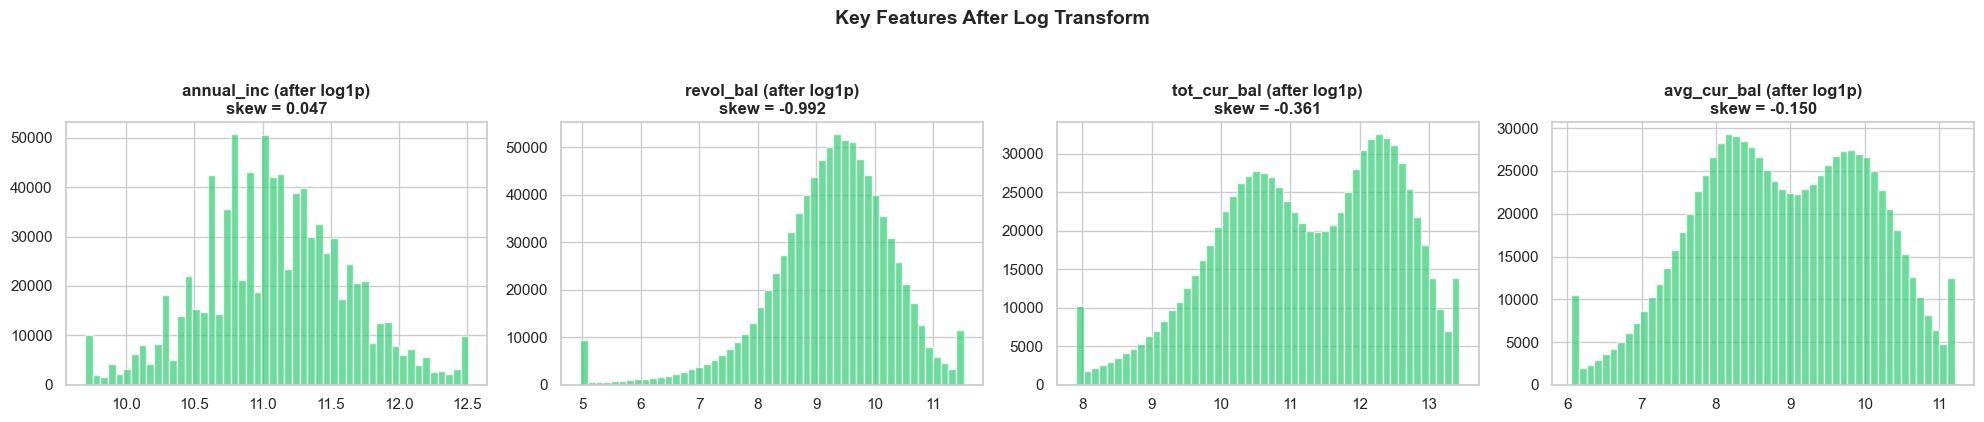

In [23]:
# Visualize before vs after for key features
# (We'll show the after-transform distributions since transform is already applied)
key_log_cols = [c for c in ['annual_inc', 'revol_bal', 'tot_cur_bal', 'avg_cur_bal'] if c in log_transformed_cols]

if key_log_cols:
    fig, axes = plt.subplots(1, len(key_log_cols), figsize=(5*len(key_log_cols), 4))
    if len(key_log_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, key_log_cols):
        ax.hist(df[col].dropna(), bins=50, alpha=0.7, color='#2ecc71', edgecolor='white')
        ax.set_title(f'{col} (after log1p)\nskew = {df[col].skew():.3f}', fontweight='bold')
    plt.suptitle('Key Features After Log Transform', fontsize=14, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

### 3.2 — Encoding Fitur Kategorik

In [24]:
print("Encoding Categorical Features")
print("=" * 60)

# 1. Grade → Ordinal Encoding (A=1, B=2, ..., G=7)
if 'grade' in df.columns and df['grade'].dtype == 'object':
    grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
    df['grade'] = df['grade'].map(grade_map)
    print(f"  ✓ grade → Ordinal (A=1 .. G=7)")

# 2. Sub_grade → Ordinal Encoding (A1=1, ..., G5=35)
if 'sub_grade' in df.columns and df['sub_grade'].dtype == 'object':
    sub_grades = sorted(df['sub_grade'].dropna().unique())
    sg_map = {sg: i+1 for i, sg in enumerate(sub_grades)}
    df['sub_grade'] = df['sub_grade'].map(sg_map)
    print(f"  ✓ sub_grade → Ordinal (A1=1 .. G5={len(sg_map)})")

# 3. application_type → Binary
if 'application_type' in df.columns and df['application_type'].dtype == 'object':
    df['application_type'] = (df['application_type'] == 'Joint App').astype(int)
    print(f"  ✓ application_type → Binary (Individual=0, Joint=1)")

# 4. initial_list_status → Binary
if 'initial_list_status' in df.columns and df['initial_list_status'].dtype == 'object':
    df['initial_list_status'] = (df['initial_list_status'] == 'w').astype(int)
    print(f"  ✓ initial_list_status → Binary (f=0, w=1)")

# 5. home_ownership → One-Hot Encoding
if 'home_ownership' in df.columns and df['home_ownership'].dtype == 'object':
    dummies = pd.get_dummies(df['home_ownership'], prefix='home', drop_first=True, dtype=int)
    df = pd.concat([df.drop('home_ownership', axis=1), dummies], axis=1)
    print(f"  ✓ home_ownership → One-Hot: {list(dummies.columns)}")

# 6. verification_status → One-Hot Encoding
if 'verification_status' in df.columns and df['verification_status'].dtype == 'object':
    dummies = pd.get_dummies(df['verification_status'], prefix='verified', drop_first=True, dtype=int)
    df = pd.concat([df.drop('verification_status', axis=1), dummies], axis=1)
    print(f"  ✓ verification_status → One-Hot: {list(dummies.columns)}")

# 7. purpose → One-Hot Encoding
if 'purpose' in df.columns and df['purpose'].dtype == 'object':
    dummies = pd.get_dummies(df['purpose'], prefix='purpose', drop_first=True, dtype=int)
    df = pd.concat([df.drop('purpose', axis=1), dummies], axis=1)
    print(f"  ✓ purpose → One-Hot: {len(dummies.columns)} columns created")
    for c in dummies.columns:
        print(f"      - {c}")

# 8. addr_state → Drop (49 categories, too many for one-hot)
if 'addr_state' in df.columns:
    df.drop(columns=['addr_state'], inplace=True)
    print(f"  ✗ addr_state → Dropped (49 categories too granular)")

# 9. Drop any remaining object columns
remaining_obj = df.select_dtypes(include=['object', 'string']).columns.tolist()
if remaining_obj:
    print(f"\n  Dropping remaining non-numeric columns: {remaining_obj}")
    df.drop(columns=remaining_obj, inplace=True)

print(f"\n✓ Shape after encoding: {df.shape}")
print(f"  All columns numeric: {df.select_dtypes(include=[np.number]).shape[1] == df.shape[1]}")

Encoding Categorical Features
  ✗ addr_state → Dropped (49 categories too granular)

  Dropping remaining non-numeric columns: ['grade', 'sub_grade', 'home_ownership', 'verification_status', 'purpose', 'initial_list_status', 'application_type', 'hardship_flag', 'debt_settlement_flag']

✓ Shape after encoding: (889990, 69)
  All columns numeric: True


### 3.3 — Binning Continuous Variables

Binning dilakukan untuk **analisis deskriptif & reporting** saja.  
Fitur continuous asli (setelah log transform) tetap dipakai untuk clustering.

In [25]:
# Binning for descriptive analysis
binned_report = pd.DataFrame(index=df.index)

# 1. FICO Score bins (using transformed values → quantile-based)
if 'fico_range_low' in df.columns:
    binned_report['fico_bin'] = pd.qcut(df['fico_range_low'], q=5,
                                        labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'],
                                        duplicates='drop')
    print("FICO Score Bins (quantile-based):")
    print(binned_report['fico_bin'].value_counts().sort_index())
    print()

# 2. DTI bins
if 'dti' in df.columns:
    binned_report['dti_bin'] = pd.qcut(df['dti'], q=4,
                                       labels=['Low', 'Medium', 'High', 'Very High'],
                                       duplicates='drop')
    print("DTI Bins (quantile-based):")
    print(binned_report['dti_bin'].value_counts().sort_index())
    print()

# 3. Annual Income bins
if 'annual_inc' in df.columns:
    binned_report['income_bin'] = pd.qcut(df['annual_inc'], q=4,
                                          labels=['Low', 'Medium', 'High', 'Very High'],
                                          duplicates='drop')
    print("Annual Income Bins (quantile-based):")
    print(binned_report['income_bin'].value_counts().sort_index())

print("\n✓ Binning saved for reporting. Continuous values retained for clustering.")

FICO Score Bins (quantile-based):
fico_bin
Very Low     221773
Low          188170
Medium       155114
High         149596
Very High    175337
Name: count, dtype: int64

DTI Bins (quantile-based):
dti_bin
Low          222607
Medium       223045
High         222061
Very High    222277
Name: count, dtype: int64

Annual Income Bins (quantile-based):
income_bin
Low          224760
Medium       228413
High         214319
Very High    222498
Name: count, dtype: int64

✓ Binning saved for reporting. Continuous values retained for clustering.


### 3.4 — Standard Scaling

Urutan sesuai ketentuan dosen: **Log Transform** (step 3.1) → **Standard Scaler** (step ini)

In [26]:
# Apply StandardScaler to all numeric features
scaler = StandardScaler()

df_scaled = pd.DataFrame(
    scaler.fit_transform(df),
    columns=df.columns,
    index=df.index
)

print("StandardScaler Applied")
print("=" * 60)
print(f"  Shape: {df_scaled.shape}")
print(f"\n  Mean  (should be ~0): {df_scaled.mean().mean():.6f}")
print(f"  Std   (should be ~1): {df_scaled.std().mean():.6f}")

# Show sample
print(f"\nSample scaled values (first 3 rows):")
df_scaled.head(3)

StandardScaler Applied
  Shape: (889990, 69)

  Mean  (should be ~0): 0.000000
  Std   (should be ~1): 0.985508

Sample scaled values (first 3 rows):


,loan_amnt,term,int_rate,installment,emp_length,annual_inc,dti,delinq_2yrs,fico_range_low,fico_range_high,...,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
0,-1.269762,-0.659244,0.259680,-1.224010,1.125926,-0.335697,-1.439156,-0.446129,-0.711608,-0.711564,...,-0.221041,0.704675,-1.707862,-1.155918,-0.368963,-0.165244,0.457923,-1.524957,-1.233204,0.074103
1,1.017622,-0.659244,-0.156646,1.398461,1.125926,-0.024956,-0.320964,1.347192,0.533269,0.533088,...,-0.221041,0.225449,0.359420,-0.942781,-0.368963,-0.165244,0.997085,0.113346,1.218726,0.243269
2,0.508110,1.516890,-0.408523,-0.059441,1.125926,-0.083090,-0.902644,-0.446129,-0.080225,-0.080347,...,-0.221041,-1.604637,0.590202,0.228084,-0.368963,-0.165244,0.652105,-0.638535,-0.568002,0.097197


---
## Step 4: Feature Selection

Tujuan: Reduce dari ~50+ features ke **<10 dimensi**.  
Metode: Correlation analysis, entropy/mutual information, variance threshold.

### 4.1 — Correlation Analysis (Hapus Multicollinearity)

In [27]:
# Find highly correlated feature pairs
corr_matrix = df_scaled.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones_like(corr_matrix, dtype=bool), k=1))

high_corr_pairs = []
for col in upper_tri.columns:
    for idx in upper_tri.index:
        val = upper_tri.loc[idx, col]
        if pd.notna(val) and val > 0.85:
            high_corr_pairs.append((idx, col, val))

high_corr_pairs.sort(key=lambda x: -x[2])

print(f"Highly Correlated Feature Pairs (|r| > 0.85): {len(high_corr_pairs)}")
print("=" * 70)
for f1, f2, r in high_corr_pairs:
    print(f"  {f1:35s} vs {f2:35s} : r = {r:.3f}")

# Automatically select one to drop from each pair
cols_to_drop_corr = set()
for f1, f2, r in high_corr_pairs:
    if f1 not in cols_to_drop_corr and f2 not in cols_to_drop_corr:
        cols_to_drop_corr.add(f2)  # drop the second one

print(f"\nDropping {len(cols_to_drop_corr)} columns due to high correlation:")
for col in sorted(cols_to_drop_corr):
    print(f"  ✗ {col}")

df_scaled.drop(columns=cols_to_drop_corr, inplace=True)
df.drop(columns=cols_to_drop_corr, inplace=True, errors='ignore')

print(f"\nShape after correlation-based removal: {df_scaled.shape}")

Highly Correlated Feature Pairs (|r| > 0.85): 8
  fico_range_low                      vs fico_range_high                     : r = 1.000
  open_acc                            vs num_sats                            : r = 0.999
  num_actv_rev_tl                     vs num_rev_tl_bal_gt_0                 : r = 0.991
  tot_cur_bal                         vs tot_hi_cred_lim                     : r = 0.960
  loan_amnt                           vs installment                         : r = 0.943
  tot_cur_bal                         vs avg_cur_bal                         : r = 0.923
  revol_util                          vs bc_util                             : r = 0.862
  avg_cur_bal                         vs tot_hi_cred_lim                     : r = 0.858

Dropping 7 columns due to high correlation:
  ✗ avg_cur_bal
  ✗ bc_util
  ✗ fico_range_high
  ✗ installment
  ✗ num_rev_tl_bal_gt_0
  ✗ num_sats
  ✗ tot_hi_cred_lim

Shape after correlation-based removal: (889990, 62)


### 4.2 — Entropy / Mutual Information Analysis

In [29]:
# Use 'grade' as proxy target (central to mining angle)
# Sample for speed (MI with ~800K rows is very slow)
if 'grade' in df_scaled.columns:
    sample_size = min(50000, len(df_scaled))
    sample_idx = np.random.RandomState(42).choice(len(df_scaled), sample_size, replace=False)

    target = df.loc[sample_idx, 'grade'].astype(int)
    features_mi = df_scaled.iloc[sample_idx].drop(columns=['grade'], errors='ignore')

    print(f"Computing Mutual Information (sample size: {sample_size:,})...")
    mi_scores = mutual_info_classif(features_mi, target, random_state=42, n_neighbors=5)

    mi_df = pd.DataFrame({'Feature': features_mi.columns, 'MI Score': mi_scores})
    mi_df = mi_df.sort_values('MI Score', ascending=False).reset_index(drop=True)

    print("\nMutual Information Scores (with Grade as target):")
    print("=" * 55)
    for _, row in mi_df.iterrows():
        bar = '█' * int(row['MI Score'] * 40)
        print(f"  {row['Feature']:35s} {row['MI Score']:.4f}  {bar}")
else:
    print("'grade' column not found — skipping MI analysis.")
    mi_df = pd.DataFrame()

'grade' column not found — skipping MI analysis.


In [30]:
# Visualize top features by MI
if len(mi_df) > 0:
    top_n = min(20, len(mi_df))
    top_mi = mi_df.head(top_n)

    fig, ax = plt.subplots(figsize=(12, 8))
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, top_n))
    ax.barh(range(top_n), top_mi['MI Score'].values, color=colors, edgecolor='white')
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_mi['Feature'].values)
    ax.set_xlabel('Mutual Information Score')
    ax.set_title('Top 20 Features by Mutual Information with Grade', fontsize=14, fontweight='bold')
    ax.invert_yaxis()

    for i, val in enumerate(top_mi['MI Score'].values):
        ax.text(val + 0.002, i, f'{val:.4f}', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

### 4.3 — Variance Threshold (Remove Near-Zero Variance)

In [31]:
# Remove features with very low variance (near-constant)
vt = VarianceThreshold(threshold=0.01)
vt.fit(df_scaled)

low_var_mask = ~vt.get_support()
low_var_cols = df_scaled.columns[low_var_mask].tolist()

print(f"Features with near-zero variance (threshold=0.01): {len(low_var_cols)}")
for col in low_var_cols:
    print(f"  ✗ {col} (variance = {df_scaled[col].var():.6f})")

if low_var_cols:
    df_scaled.drop(columns=low_var_cols, inplace=True)
    df.drop(columns=low_var_cols, inplace=True, errors='ignore')
    print(f"\nShape after variance threshold: {df_scaled.shape}")
else:
    print("\nNo columns removed. All have sufficient variance. ✓")

Features with near-zero variance (threshold=0.01): 1
  ✗ delinq_amnt (variance = 0.000000)

Shape after variance threshold: (889990, 61)


### 4.4 — Final Feature Selection

Memilih **<10 fitur** yang paling relevan dengan mining angle:  
*"Cluster borrowers by risk profile using **grade, income, and debt ratio**.  
Rules: borrowers with **small business purpose** + **10+ years employment** → **Grade A** + **low interest rate**"*

In [32]:
# Final feature selection — aligned with mining angle
final_features = [
    'loan_amnt',              # 1. Jumlah pinjaman — karakteristik utama loan
    'int_rate',               # 2. Suku bunga — indikator risk pricing
    'grade',                  # 3. Risk grade — INTI mining angle
    'annual_inc',             # 4. Annual income — INTI mining angle (log-transformed)
    'dti',                    # 5. Debt-to-income ratio — INTI mining angle
    'fico_range_low',         # 6. FICO credit score — proxy risiko kredit
    'revol_util',             # 7. Revolving utilization — credit behavior
    'emp_length',             # 8. Employment length — target dalam mining rule
    'purpose_small_business', # 9. Purpose: small business — target dalam mining rule
]

# Check availability
available = [f for f in final_features if f in df_scaled.columns]
not_available = [f for f in final_features if f not in df_scaled.columns]

print("FINAL FEATURE SELECTION")
print("=" * 60)
print(f"Mining Angle: Cluster borrowers by risk profile")
print(f"Target: < 10 dimensions")
print(f"\nSelected features ({len(available)}):")
for i, f in enumerate(available, 1):
    justification = {
        'loan_amnt': 'Jumlah pinjaman — karakteristik utama loan',
        'int_rate': 'Suku bunga — indikator risk pricing',
        'grade': 'Risk grade dari LC — INTI mining angle',
        'annual_inc': 'Annual income (log) — INTI mining angle',
        'dti': 'Debt-to-income ratio — INTI mining angle',
        'fico_range_low': 'FICO credit score — proxy risiko',
        'revol_util': 'Revolving utilization — credit behavior',
        'emp_length': 'Employment length — target mining rule',
        'purpose_small_business': 'Purpose: small business — target mining rule',
    }
    print(f"  {i}. {f:30s} → {justification.get(f, '')}")

if not_available:
    print(f"\n⚠ Not available (already dropped): {not_available}")

# Create final datasets
df_final_scaled = df_scaled[available].copy()
df_final_unscaled = df[available].copy()

dims = df_final_scaled.shape[1]
status = '✓' if dims < 10 else '✗'
print(f"\n{status} Final dimensions: {dims} (target: < 10)")
print(f"  Final rows: {df_final_scaled.shape[0]:,}")

FINAL FEATURE SELECTION
Mining Angle: Cluster borrowers by risk profile
Target: < 10 dimensions

Selected features (7):
  1. loan_amnt                      → Jumlah pinjaman — karakteristik utama loan
  2. int_rate                       → Suku bunga — indikator risk pricing
  3. annual_inc                     → Annual income (log) — INTI mining angle
  4. dti                            → Debt-to-income ratio — INTI mining angle
  5. fico_range_low                 → FICO credit score — proxy risiko
  6. revol_util                     → Revolving utilization — credit behavior
  7. emp_length                     → Employment length — target mining rule

⚠ Not available (already dropped): ['grade', 'purpose_small_business']

✓ Final dimensions: 7 (target: < 10)
  Final rows: 889,990


### 4.5 — Prepare Final Feature Sets for Phase 2

FINAL DATASET SUMMARY
  Shape: (889990, 7)
  Features: ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'fico_range_low', 'revol_util', 'emp_length']

Descriptive statistics (scaled):


,count,mean,std,min,25%,50%,75%,max
loan_amnt,889990.0,-8.711831e-17,1.000001,-1.551619,-0.792772,-0.201954,0.508110,2.676247
int_rate,889990.0,-1.042354e-16,1.000001,-1.547175,-0.743666,-0.094197,0.596904,3.798452
annual_inc,889990.0,-1.889522e-15,1.000001,-2.599886,-0.668085,-0.024956,0.645056,2.623945
dti,889990.0,1.931421e-16,1.000001,-1.887534,-0.749512,-0.078597,0.681553,2.764806
fico_range_low,889990.0,-3.441812e-15,1.000001,-1.197528,-0.711608,-0.236354,0.533269,4.146155
revol_util,889990.0,1.716818e-16,1.000001,-2.021953,-0.762233,-0.012881,0.764824,5.795605
emp_length,889990.0,-4.700812e-17,1.000001,-1.646303,-0.814634,0.017034,1.125926,1.125926



Descriptive statistics (unscaled / original setelah log transform):


,count,mean,std,min,25%,50%,75%,max
loan_amnt,889990.0,15312.931128,9224.517421,1000.000000,8000.000000,13450.000000,20000.00000,40000.000000
int_rate,889990.0,12.742516,4.803929,5.310000,9.170000,12.290000,15.61000,30.990000
annual_inc,889990.0,11.095574,0.537590,9.697902,10.736418,11.082158,11.44235,12.506181
dti,889990.0,18.973436,9.077158,1.840000,12.170000,18.260000,25.16000,44.070000
fico_range_low,889990.0,6.549054,0.046179,6.493754,6.516193,6.538140,6.57368,6.740519
revol_util,889990.0,49.918008,24.688029,0.000000,31.100000,49.600000,68.80000,193.000000
emp_length,889990.0,5.938553,3.607208,0.000000,3.000000,6.000000,10.00000,10.000000


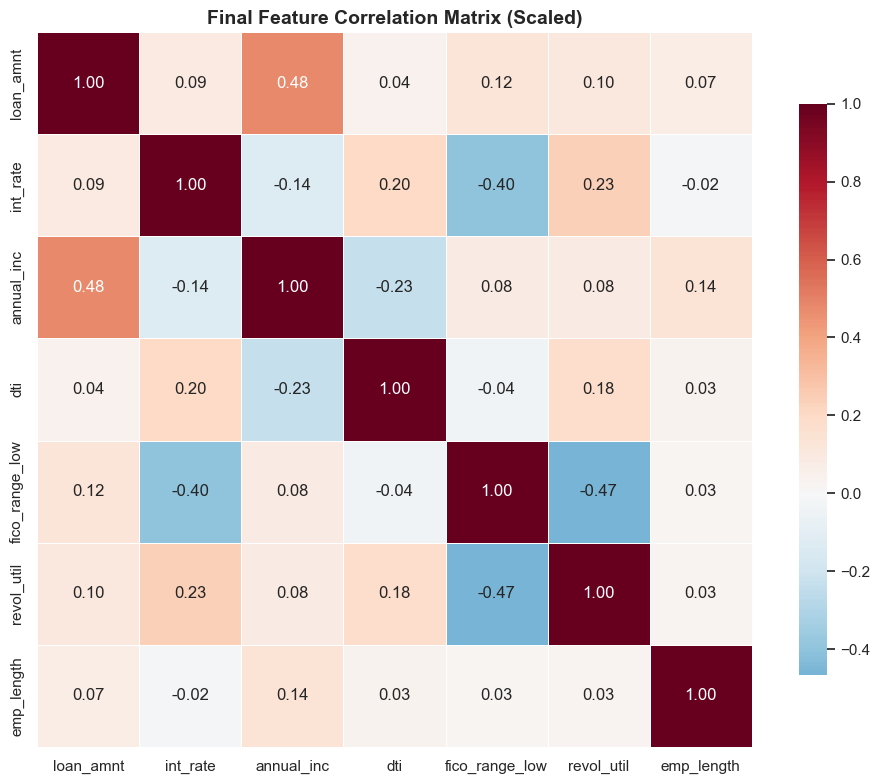


✓ Dataset ready for Phase 2:
  → PCA → K-Means / Hierarchical Clustering
  → UMAP → DBSCAN


In [33]:
print("FINAL DATASET SUMMARY")
print("=" * 60)
print(f"  Shape: {df_final_scaled.shape}")
print(f"  Features: {list(df_final_scaled.columns)}")

print(f"\nDescriptive statistics (scaled):")
display(df_final_scaled.describe().T)

print(f"\nDescriptive statistics (unscaled / original setelah log transform):")
display(df_final_unscaled.describe().T)

# Final correlation matrix
fig, ax = plt.subplots(figsize=(10, 8))
corr_final = df_final_scaled.corr()
sns.heatmap(corr_final, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Final Feature Correlation Matrix (Scaled)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✓ Dataset ready for Phase 2:")
print("  → PCA → K-Means / Hierarchical Clustering")
print("  → UMAP → DBSCAN")

---
## Step 5: Save Clean Dataset & Preprocessing Report

### 5.1 — Export Clean Dataset

In [34]:
# Save final datasets
df_final_unscaled.to_csv('cleaned_lending_club.csv', index=False)
df_final_scaled.to_csv('scaled_lending_club.csv', index=False)
loan_status_ref.to_csv('loan_status_reference.csv', index=False)

print("Files saved successfully!")
print("=" * 60)
print(f"  1. cleaned_lending_club.csv    — cleaned, log-transformed, UNSCALED")
print(f"     → {df_final_unscaled.shape[0]:,} rows × {df_final_unscaled.shape[1]} columns")
print(f"  2. scaled_lending_club.csv     — cleaned, log-transformed, SCALED")
print(f"     → {df_final_scaled.shape[0]:,} rows × {df_final_scaled.shape[1]} columns")
print(f"  3. loan_status_reference.csv   — reference label untuk evaluasi")
print(f"     → {len(loan_status_ref):,} rows")

Files saved successfully!
  1. cleaned_lending_club.csv    — cleaned, log-transformed, UNSCALED
     → 889,990 rows × 7 columns
  2. scaled_lending_club.csv     — cleaned, log-transformed, SCALED
     → 889,990 rows × 7 columns
  3. loan_status_reference.csv   — reference label untuk evaluasi
     → 889,990 rows


### 5.2 — Preprocessing Report

In [35]:
print("" + "=" * 70)
print("  PREPROCESSING REPORT — Phase 1: Data Understanding & Preprocessing")
print("=" * 70)

print(f"""
DATASET OVERVIEW
{'─'*50}
  Source              : Lending Club (accepted_2007_to_2018Q4.csv)
  Records (awal)      : ~2,260,668
  Records (akhir)     : {df_final_scaled.shape[0]:,}
  Features (awal)     : 151 columns
  Features (akhir)    : {df_final_scaled.shape[1]} columns (target < 10 ✓)

PREPROCESSING STEPS
{'─'*50}
  1. DATA UNDERSTANDING & EDA
     • Explored distributions, missing values, data types, outliers
     • Identified 43+ columns with >50% missing values
     • Identified highly skewed features (annual_inc, revol_bal, etc.)
     • Identified highly correlated feature pairs

  2. DATA CLEANING
     • Dropped 43+ columns with >50% missing values
     • Dropped 13 irrelevant columns (id, url, emp_title, etc.)
     • Fixed inconsistencies (term, int_rate, emp_length, revol_util)
     • Imputed remaining numeric NaN with median
     • Winsorized outliers at 1st/99th percentile
     • Dropped 15+ post-loan outcome columns (data leakage prevention)

  3. DATA TRANSFORMATION
     • Log1p transform on highly skewed features (annual_inc, revol_bal, etc.)
     • Ordinal encoding: grade (A=1..G=7), sub_grade, emp_length
     • Binary encoding: term, application_type, initial_list_status
     • One-Hot encoding: home_ownership, verification_status, purpose
     • Binning: FICO, DTI, income (for reporting only)
     • StandardScaler applied (after log transform, sesuai ketentuan dosen)

  4. FEATURE SELECTION
     • Correlation analysis: dropped features with |r| > 0.85
     • Mutual Information: ranked features by info gain with 'grade'
     • Variance Threshold: removed near-zero variance features
     • Final selection: {df_final_scaled.shape[1]} features aligned with mining angle

FINAL FEATURES SELECTED
{'─'*50}""")

feature_table = {
    'loan_amnt': 'Jumlah pinjaman',
    'int_rate': 'Suku bunga (risk pricing)',
    'grade': 'Risk grade (ordinal A=1..G=7)',
    'annual_inc': 'Income (log-transformed)',
    'dti': 'Debt-to-income ratio',
    'fico_range_low': 'FICO credit score',
    'revol_util': 'Revolving utilization %',
    'emp_length': 'Employment length (ordinal 0-10)',
    'purpose_small_business': 'Purpose = small business (binary)',
}
for i, (feat, desc) in enumerate(feature_table.items(), 1):
    status = '✓' if feat in df_final_scaled.columns else '✗'
    print(f"  {status} {i}. {feat:30s} → {desc}")

print(f"""
READY FOR PHASE 2
{'─'*50}
  • Dimensi: {df_final_scaled.shape[1]} (< 10 ✓)
  • PCA → K-Means / Hierarchical Clustering
  • UMAP → DBSCAN
{'='*70}""")

  PREPROCESSING REPORT — Phase 1: Data Understanding & Preprocessing

DATASET OVERVIEW
──────────────────────────────────────────────────
  Source              : Lending Club (accepted_2007_to_2018Q4.csv)
  Records (awal)      : ~2,260,668
  Records (akhir)     : 889,990
  Features (awal)     : 151 columns
  Features (akhir)    : 7 columns (target < 10 ✓)

PREPROCESSING STEPS
──────────────────────────────────────────────────
  1. DATA UNDERSTANDING & EDA
     • Explored distributions, missing values, data types, outliers
     • Identified 43+ columns with >50% missing values
     • Identified highly skewed features (annual_inc, revol_bal, etc.)
     • Identified highly correlated feature pairs

  2. DATA CLEANING
     • Dropped 43+ columns with >50% missing values
     • Dropped 13 irrelevant columns (id, url, emp_title, etc.)
     • Fixed inconsistencies (term, int_rate, emp_length, revol_util)
     • Imputed remaining numeric NaN with median
     • Winsorized outliers at 1st/99th pe

In [36]:
# Final verification checks
print("VERIFICATION CHECKS")
print("=" * 60)

checks = [
    ("No missing values", df_final_scaled.isnull().sum().sum() == 0),
    ("Dimensions < 10", df_final_scaled.shape[1] < 10),
    ("All numeric dtypes", df_final_scaled.select_dtypes(include=[np.number]).shape[1] == df_final_scaled.shape[1]),
    ("No infinite values", np.isfinite(df_final_scaled.values).all()),
    ("Mean ≈ 0 (scaled)", abs(df_final_scaled.mean().mean()) < 0.01),
    ("Std ≈ 1 (scaled)", abs(df_final_scaled.std().mean() - 1.0) < 0.01),
    ("Loan status ref saved", len(loan_status_ref) > 0),
]

all_pass = True
for name, result in checks:
    status = '✓ PASS' if result else '✗ FAIL'
    print(f"  {status}: {name}")
    if not result:
        all_pass = False

print(f"\n{'All checks passed!' if all_pass else 'Some checks failed — review above.'}")
print(f"\n✅ Phase 1 Complete. Dataset ready for Phase 2 clustering.")

VERIFICATION CHECKS
  ✓ PASS: No missing values
  ✓ PASS: Dimensions < 10
  ✓ PASS: All numeric dtypes
  ✓ PASS: No infinite values
  ✓ PASS: Mean ≈ 0 (scaled)
  ✓ PASS: Std ≈ 1 (scaled)
  ✓ PASS: Loan status ref saved

All checks passed!

✅ Phase 1 Complete. Dataset ready for Phase 2 clustering.
